In [109]:
import torch

In [110]:
### Select device (GPU)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'

print('Selected device:', device)

Selected device: cuda


In [111]:
import random

### Reading data set ###

with open('../data-sets/tiny_shakespeare.txt', 'r', encoding='utf-8') as f:
    text = f.read()

dataset = text

print('Random line:', random.choice(dataset.split('\n')))
print('Size of dataset:', len(dataset.split('\n')), 'lines')

Random line: Let's to the Capitol;
Size of dataset: 40001 lines


In [112]:
unique_chars = sorted(set(dataset))

char_to_num = {char: num for num, char in enumerate(unique_chars)}
num_to_char = {num: char for char, num in char_to_num.items()}

vocab_size = len(unique_chars) # Vocabulary size |V|

print(unique_chars)
print('Number of unique chars:', vocab_size)

['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Number of unique chars: 65


In [113]:
### Process data set ###

train_frac = 0.95
seq_length = 75

def build_dataset(data):
    X, Y = [], []
    
    context = [0] * seq_length
    
    for ch in data:
        X.append(context)
        ix = char_to_num[ch]
        context = context[1:] + [ix]
        Y.append(context)

    X = torch.tensor(X)
    Y = torch.tensor(Y)

    return X, Y

split = int(train_frac * len(dataset))

Xtr, Ytr = build_dataset(dataset[:split])
Xte, Yte = build_dataset(dataset[split:])

print('Example shape:', Xtr[0].shape, '=>', Ytr[0].shape)
print('Amount of train examples:', len(Xtr))

Example shape: torch.Size([75]) => torch.Size([75])
Amount of train examples: 1059624


In [114]:
import torch.nn as nn

### Create recurrent neural network ###

emb_dim = 60
hidden_size = 200

class RNN(nn.Module):
    
    def __init__(self, hidden_size, num_layers=1):
        super(RNN, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embeddings = nn.Embedding(vocab_size, emb_dim)
        self.rnn        = nn.RNN(emb_dim, hidden_size, num_layers, batch_first=True)
        self.fc         = nn.Linear(hidden_size, vocab_size)

    def forward(self, input, hidden):    
        embs = self.embeddings(input) # (B x Seq len x emb dim)

        output, hidden = self.rnn(embs, hidden)
        output = self.fc(output)

        if input.dim() == 2:
            output = output.permute(0, 2, 1)
        
        return output, hidden

    def init_hidden(self, batch_size=None):
        if batch_size is None:
            return torch.zeros(self.num_layers, self.hidden_size).to(device)
        else:
            return torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)


model = RNN(hidden_size).to(device)

print('Total parameters:', sum(p.numel() for p in model.parameters()))

Total parameters: 69365


In [115]:
lr = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [116]:
from tqdm import trange
import torch.nn.functional as F

### Train network ###

epochs = 50000
batch_size = 64
eval_batch_size = 9600

epoch_count       = []
train_loss_values = []
test_loss_values  = []
gradients_norm    = []


for epoch in trange(epochs):
    
    # Sample mini-batch and send to gpu
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix].to(device), Ytr[ix].to(device)

    hidden = model.init_hidden(batch_size) # Initialize hidden state
    output, _ = model(Xb, hidden)          # Do the forward pass
    loss = criterion(output, Yb)           # Calculate the loss
    optimizer.zero_grad()                  # Reset parameters
    loss.backward()                        # Backpropagation
    optimizer.step()                       # Update parameters

    # Report progression every so often
    if ((epoch + 1) % (epochs / 50) == 0):

        gradients_norm.append(
            torch.tensor(
                [torch.norm(param.grad).item() for param in model.parameters() if param.grad is not None]
            ).norm().item())

        with torch.inference_mode():
        
            # Sample larger train-batch
            ix = torch.randint(0, Xtr.shape[0], (eval_batch_size,))
            Xb, Yb = Xtr[ix].to(device), Ytr[ix].to(device)
            
            hidden = model.init_hidden(eval_batch_size)
            output, _ = model(Xb, hidden)
            loss = F.cross_entropy(output, Yb)

            # Sample larger test-batch
            ix = torch.randint(0, Xte.shape[0], (eval_batch_size,))
            Xb, Yb = Xte[ix].to(device), Yte[ix].to(device)

            hidden = model.init_hidden(eval_batch_size)
            output, _ = model(Xb, hidden)
            test_loss = F.cross_entropy(output, Yb)
            
            # Log data
            epoch_count.append(epoch)
            train_loss_values.append(loss.item())
            test_loss_values.append(test_loss.item())


# Print final results
print()
print('Final training loss:', round(loss.item(), 3))
print('Final test loss:    ', round(test_loss.item(), 3))

  0%|          | 0/50000 [00:00<?, ?it/s]

100%|██████████| 50000/50000 [01:46<00:00, 469.96it/s]


Final training loss: 1.36
Final test loss:     1.732


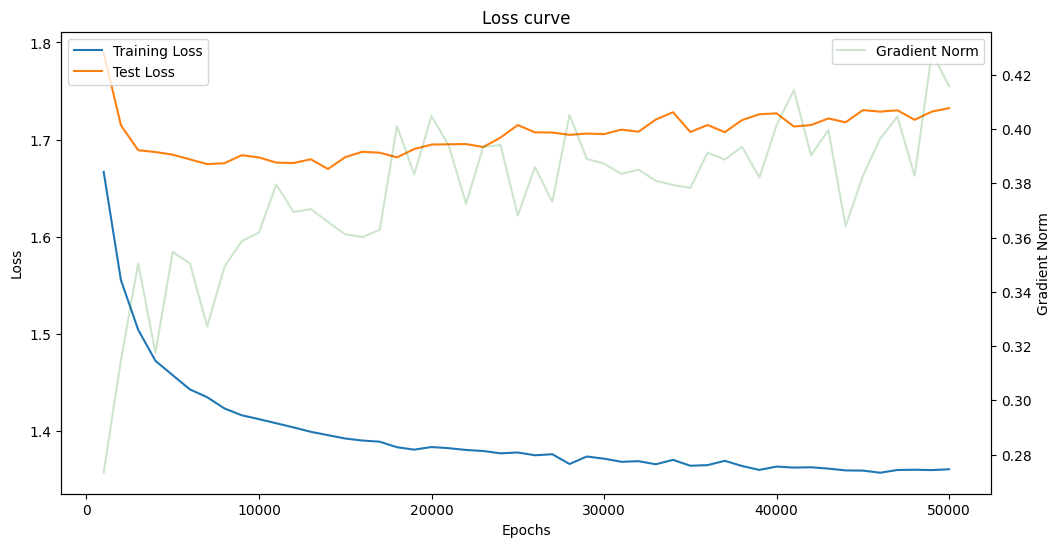

In [117]:
import matplotlib.pyplot as plt

### Visualize loss progression ###

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot training and test loss on the left y-axis
ax1.plot(epoch_count, train_loss_values, label="Training Loss")
ax1.plot(epoch_count, test_loss_values, label="Test Loss")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.set_title("Loss curve")

# Plot gradient norm on the right y-axis
ax2 = ax1.twinx()
ax2.plot(epoch_count, gradients_norm, 'g', alpha=0.2, label="Gradient Norm")
ax2.set_ylabel("Gradient Norm")

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()

In [118]:
### Use model ###

@torch.inference_mode()
def evaluate(model, start='\n', length=1000):
    hidden = model.init_hidden()
    prime_input = torch.tensor([char_to_num[c] for c in start])

    # Build up hidden state with input text
    for i in range(len(start) - 1):
        _, hidden = model(prime_input[i].unsqueeze(0).to(device), hidden)

    predicted = start

    # Generate new sequence based on hidden state
    input = prime_input[-1].unsqueeze(0)
    for _ in range(length):
        output, hidden = model(input.to(device), hidden)

        probs = F.softmax(output, dim=1)
        ix = torch.multinomial(probs, num_samples=1)[0]

        char = num_to_char[ix.item()]
        predicted += char
        input = ix
    
    return predicted


print(evaluate(model, 'I said '))

I said say thy leave
I pray you! well me with ashintous upon me be unfeight make not your sciss stay.

PAULINA:
No, if I mays.

KING RICHARD IIIO:
Emforse Lucio, that good contramed which of with milce steelabour!
Held wind,
That we physing and does wels betity that that is a mindd my
to look to blunt!

OXFORD:
None should be Warwick's good slarge.

KATHARINA:
I do be proffall'd in prid carried and starve with orators.

DUKE Vim,
Shall he that this your done; belly, but is a blphat more than goes; fire, both see, towlivel, scotcegents, yours towards and upon our adudy dipenings might hear I cusuins to keep the eat to pass, you will fear, I proport; ner.

First Lord:
Away.
Is I unlawd.

CAMILLO:
He's a malice no spare and violets is defining royal wines.
Hear'st to the very cast up, cease a kinsman's name will he have tambled to be done?

MENENIUS:
O, they ender roat, cowful: I pray you fight! pay when it, God call himself. Ha!

YORK:

PAULINA:
Mekeld the way, hark cause.
Well nothing p